In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('spam.csv',encoding='latin-1')

In [3]:
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3182,ham,Dunno i juz askin cos i got a card got 20% off...,NaN,NaN,NaN
1848,ham,I dont want to hear philosophy. Just say what ...,NaN,NaN,NaN
1714,ham,Yeah I don't see why not,NaN,NaN,NaN
2212,ham,This is one of the days you have a billion cla...,NaN,NaN,NaN
4248,ham,Loosu go to hospital. De dont let it careless.,NaN,NaN,NaN
1934,ham,Hope you are having a great day.,NaN,NaN,NaN
2379,ham,"Good evening Sir, hope you are having a nice d...",NaN,NaN,NaN
3604,ham,Jordan got voted out last nite!,NaN,NaN,NaN
3616,ham,Sorry sent blank msg again. Yup but trying 2 d...,NaN,NaN,NaN
2657,ham,Dai &lt;#&gt; naal eruku.,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [7]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [8]:
df.sample(5)

,v1,v2
430,ham,At home watching tv lor.
2148,ham,I will once i get home
1526,ham,"Wow ... I love you sooo much, you know ? I can..."
902,ham,I wonder if your phone battery went dead ? I h...
598,ham,Will do. Was exhausted on train this morning. ...


In [9]:
df.rename(columns={'v1':'Target','v2':'Message'},inplace=True)

In [10]:
df.sample(5)

,Target,Message
171,ham,"Hmmm.. Thk sure got time to hop ard... Ya, can..."
2917,ham,Thanks chikku..:-) gud nyt:-*
116,spam,You are a winner U have been specially selecte...
3410,ham,Only once then after ill obey all yours.
2155,ham,What year. And how many miles.


In [11]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [12]:
df.isnull().sum()

Target     0
Message    0
dtype: int64

In [13]:
df['Target'] = encoder.fit_transform(df['Target'])

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Target   5572 non-null   int64
 1   Message  5572 non-null   str  
dtypes: int64(1), str(1)
memory usage: 87.2 KB


In [15]:
df.head

<bound method NDFrame.head of       Target                                            Message
0          0  Go until jurong point, crazy.. Available only ...
1          0                      Ok lar... Joking wif u oni...
2          1  Free entry in 2 a wkly comp to win FA Cup fina...
3          0  U dun say so early hor... U c already then say...
4          0  Nah I don't think he goes to usf, he lives aro...
...      ...                                                ...
5567       1  This is the 2nd time we have tried 2 contact u...
5568       0              Will Ì_ b going to esplanade fr home?
5569       0  Pity, * was in mood for that. So...any other s...
5570       0  The guy did some bitching but I acted like i'd...
5571       0                         Rofl. Its true to its name

[5572 rows x 2 columns]>

In [16]:
df.sample(10)

,Target,Message
3218,0,Me too baby! I promise to treat you well! I be...
354,0,&lt;#&gt; ISH MINUTES WAS 5 MINUTES AGO. WTF.
5293,0,I donno its in your genes or something
346,0,Dis is yijue. I jus saw ur mail. In case huimi...
5334,0,"Garbage bags, eggs, jam, bread, hannaford whea..."
3862,1,Oh my god! I've found your number again! I'm s...
2559,0,I also thk too fast... Xy suggest one not me. ...
2972,0,Happy New Year Princess!
2165,0,I'm not coming home 4 dinner.
630,0,Please dont say like that. Hi hi hi


In [17]:
df.duplicated().sum()

np.int64(403)

In [18]:
df = df.drop_duplicates(keep ='first')

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.shape

(5169, 2)

In [21]:
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

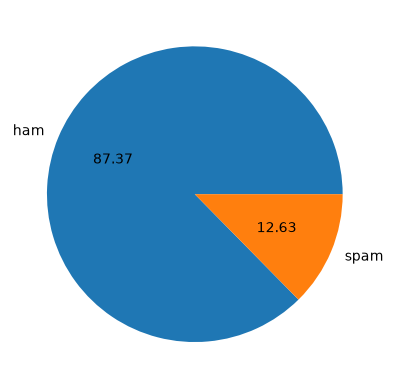

In [22]:
 plt.pie(df['Target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')

In [23]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import nltk

In [25]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [26]:
df['num_characters']=df['Message'].apply(len)

In [27]:
df.head

<bound method NDFrame.head of       Target                                            Message  \
0          0  Go until jurong point, crazy.. Available only ...   
1          0                      Ok lar... Joking wif u oni...   
2          1  Free entry in 2 a wkly comp to win FA Cup fina...   
3          0  U dun say so early hor... U c already then say...   
4          0  Nah I don't think he goes to usf, he lives aro...   
...      ...                                                ...   
5567       1  This is the 2nd time we have tried 2 contact u...   
5568       0              Will Ì_ b going to esplanade fr home?   
5569       0  Pity, * was in mood for that. So...any other s...   
5570       0  The guy did some bitching but I acted like i'd...   
5571       0                         Rofl. Its true to its name   

      num_characters  
0                111  
1                 29  
2                155  
3                 49  
4                 61  
...              ...  
5567

In [28]:
df.sample(5)

,Target,Message,num_characters
4913,0,You've already got a flaky parent. It'snot sup...,237
5556,0,Yes i have. So that's why u texted. Pshew...mi...,63
1817,0,Well i will watch shrek in 3D!!B),33
3591,0,I anything lor...,17
3250,0,"IÛ÷ll leave around four, ok?",29


In [29]:
df['Message'].apply(lambda x:nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: Message, Length: 5169, dtype: object

In [30]:
print(nltk.__version__)

3.9.4


In [31]:
df['num_words']=df['Message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [32]:
df.head()

,Target,Message,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [33]:
df['num_sent']=df['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [34]:
df.head()

,Target,Message,num_characters,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
